In [5]:
import pandas as pd
import numpy as np
import os, sys

import matplotlib.pyplot as plt

# Path to: project/
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Path to: project/src
src_path = os.path.join(project_root, "src")

# Add to import path
sys.path.append(src_path)

from preprocessing import clean_data

In [6]:
# Import
df = pd.read_csv('../data/train.csv')

df = clean_data(df)

In [7]:
target_col = 'totalRent' 
features = df.columns.to_list()
features.remove(target_col)
output = []
for feature in features:
    X = df[feature]
    Y = df[target_col]
    r_value = X.corr(Y)
    output.append({'feature': feature, "r2": r_value})

In [8]:
output

[{'feature': 'serviceCharge', 'r2': np.float64(0.7603222482157175)},
 {'feature': 'heatingType_num', 'r2': np.float64(0.16210240376545468)},
 {'feature': 'newlyConst_num', 'r2': np.float64(0.20196789941159352)},
 {'feature': 'balcony_num', 'r2': np.float64(-0.29907876344666506)},
 {'feature': 'picturecount', 'r2': np.float64(0.38277785122051305)},
 {'feature': 'pricetrend', 'r2': np.float64(-0.007570928275645899)},
 {'feature': 'telekomUploadSpeed', 'r2': np.float64(0.046601940070340526)},
 {'feature': 'yearConstructed', 'r2': np.float64(0.07933802358642658)},
 {'feature': 'scoutId', 'r2': np.float64(0.11306769775624143)},
 {'feature': 'noParkSpaces', 'r2': np.float64(0.12572344241003935)},
 {'feature': 'firingTypes_num', 'r2': np.float64(0.146118500443119)},
 {'feature': 'hasKitchen_num', 'r2': np.float64(-0.1277553139744898)},
 {'feature': 'cellar_num', 'r2': np.float64(-0.1372253762692812)},
 {'feature': 'yearConstructedRange', 'r2': np.float64(0.22022753723496183)},
 {'feature': 'b

In [9]:
nan_features = [item['feature'] for item in output if np.isnan(item['r2'])]

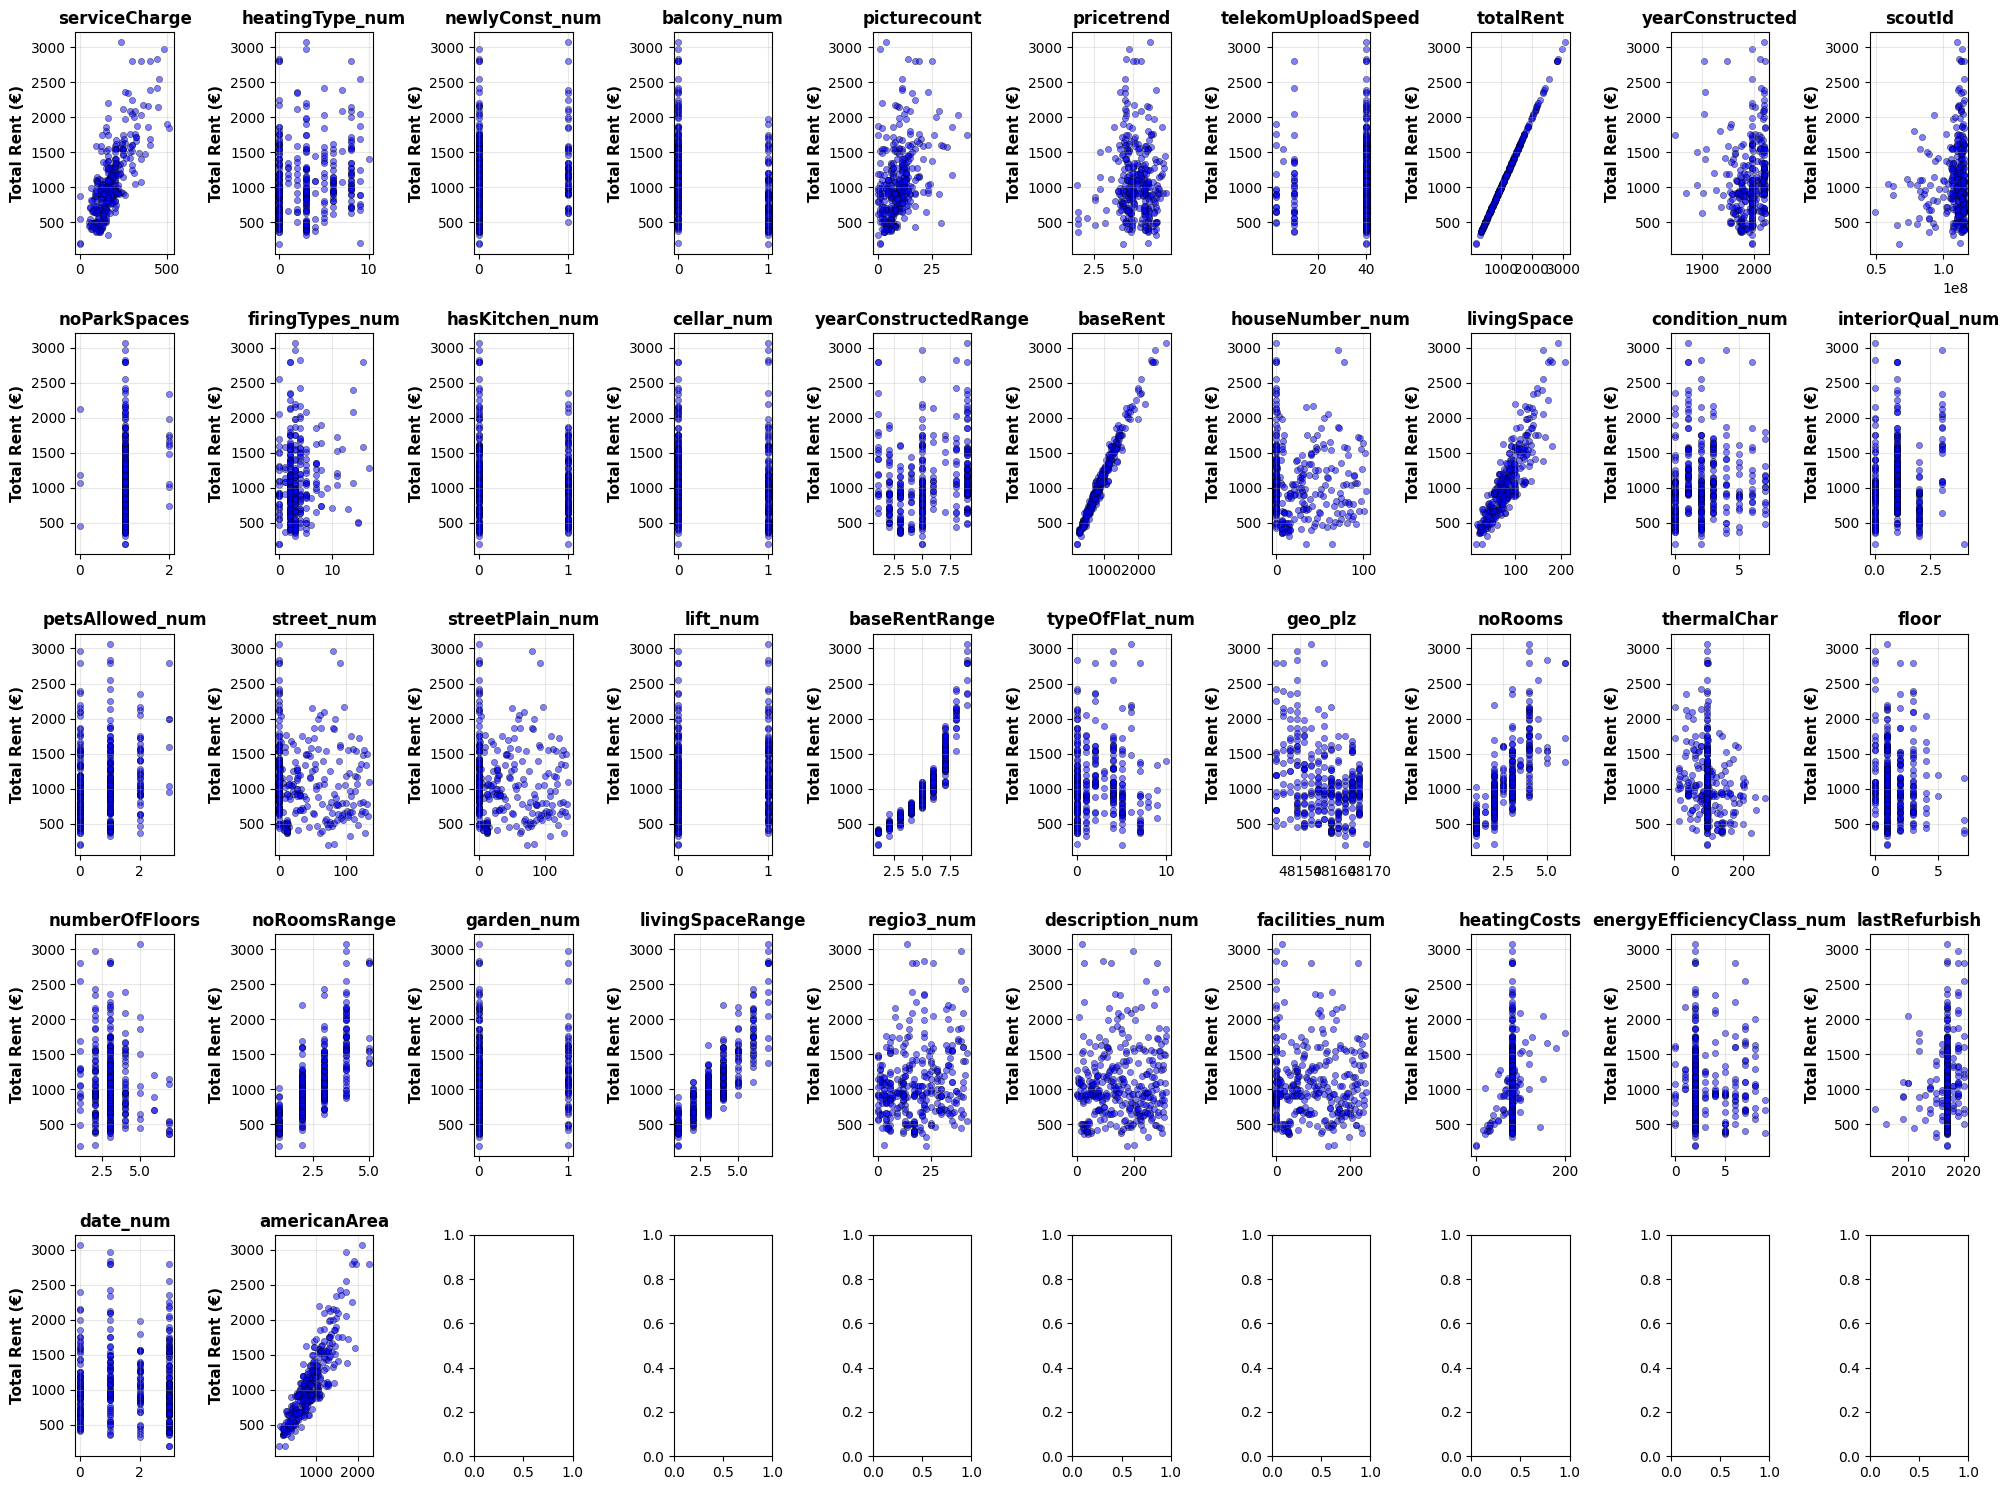

In [10]:
def plot_scatter_matrix(
    df: pd.DataFrame, 
    df_cols: list[str], 
    target: str,
    highlight: list[str] = None
) -> None:
    
    # Create a grid of scatter plots
    fig, axes = plt.subplots(5, 10, figsize=(20, 15))
    axes = axes.flatten()

    # Default: no highlights
    highlight = highlight or []

    for i, feature in enumerate(df_cols):
        ax = axes[i]

        # Choose color depending on highlight
        color = "red" if feature in highlight else "blue"
        
        # Create scatter plot
        ax.scatter(
            df[feature], 
            df[target], 
            alpha=0.5, 
            s=20,
            edgecolor='k', 
            linewidth=0.5,
            color=color
        )

        ax.set_ylabel('Total Rent (€)', fontsize=11, fontweight='bold')
        ax.set_title(feature, fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_scatter_matrix(df, df.columns.to_list(), target_col, nan_features )

In [ ]:
['regio1_num', 'telekomTvOffer_num', 'telekomHybridUploadSpeed', 'geo_bln_num', 'geo_krs_num', 'regio2_num', 'electricityBasePrice', 'electricityKwhPrice']

In [13]:
df.columns.to_list()

['serviceCharge',
 'heatingType_num',
 'newlyConst_num',
 'balcony_num',
 'picturecount',
 'pricetrend',
 'telekomUploadSpeed',
 'totalRent',
 'yearConstructed',
 'scoutId',
 'noParkSpaces',
 'firingTypes_num',
 'hasKitchen_num',
 'cellar_num',
 'yearConstructedRange',
 'baseRent',
 'houseNumber_num',
 'livingSpace',
 'condition_num',
 'interiorQual_num',
 'petsAllowed_num',
 'street_num',
 'streetPlain_num',
 'lift_num',
 'baseRentRange',
 'typeOfFlat_num',
 'geo_plz',
 'noRooms',
 'thermalChar',
 'floor',
 'numberOfFloors',
 'noRoomsRange',
 'garden_num',
 'livingSpaceRange',
 'regio3_num',
 'description_num',
 'facilities_num',
 'heatingCosts',
 'energyEfficiencyClass_num',
 'lastRefurbish',
 'date_num',
 'americanArea']

In [15]:
old_columns = ['regio1_num', 'serviceCharge', 'heatingType_num', 'telekomTvOffer_num', 'telekomHybridUploadSpeed', 'newlyConst_num', 'balcony_num', 'picturecount', 'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed', 'scoutId', 'noParkSpaces', 'firingTypes_num', 'hasKitchen_num', 'geo_bln_num', 'cellar_num', 'yearConstructedRange', 'baseRent', 'houseNumber_num', 'livingSpace', 'geo_krs_num', 'condition_num', 'interiorQual_num', 'petsAllowed_num', 'street_num', 'streetPlain_num', 'lift_num', 'baseRentRange', 'typeOfFlat_num', 'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'noRoomsRange', 'garden_num', 'livingSpaceRange', 'regio2_num', 'regio3_num', 'description_num', 'facilities_num', 'heatingCosts', 'energyEfficiencyClass_num', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date_num', 'americanArea']
len(old_columns)

50

In [16]:
diff = [x for x in old_columns if x not in df.columns.to_list()]
diff

['regio1_num',
 'telekomTvOffer_num',
 'telekomHybridUploadSpeed',
 'geo_bln_num',
 'geo_krs_num',
 'regio2_num',
 'electricityBasePrice',
 'electricityKwhPrice']